In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from tensorflow.keras import models, layers

In [2]:
def simulate_vdp(mu=1.0, dt=0.02, T=20.0, x0=2.0, y0=0.0):
    n_steps = int(T / dt)

    t = np.linspace(0, T, n_steps)
    x = np.zeros(n_steps)
    y = np.zeros(n_steps)

    x[0] = x0
    y[0] = y0

    for i in range(1, n_steps):
        dxdt = y[i-1]
        dydt = mu * (1 - x[i-1]**2) * y[i-1] - x[i-1]

        x[i] = x[i-1] + dxdt * dt
        y[i] = y[i-1] + dydt * dt

    return t, x, y

In [3]:
def neural_smooth(t, noisy_states, epochs=300):
    t_normalized = (t - t.min()) / (t.max() - t.min())
    t_normalized = t_normalized.reshape(-1, 1)

    model = models.Sequential([
        layers.Input(shape=(1,)),
        layers.Dense(128, activation="tanh"),
        layers.Dense(128, activation="tanh"),
        layers.Dense(2)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    model.fit(
        t_normalized,
        noisy_states,
        epochs=epochs,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )

    smoothed_states = model.predict(t_normalized, verbose=0)

    return smoothed_states

In [4]:
def discover_vdp_equations(t, x, y, alpha=0.001):
    dxdt = np.gradient(x, t)
    dydt = np.gradient(y, t)

    Theta = np.column_stack([
        np.ones_like(x),
        x,
        y,
        x**2,
        x*y,
        y**2,
        x**3,
        (x**2)*y,
        x*(y**2),
        y**3
    ])

    feature_names = [
        "1",
        "x",
        "y",
        "x^2",
        "xy",
        "y^2",
        "x^3",
        "x^2y",
        "xy^2",
        "y^3"
    ]

    lasso_dx = Lasso(alpha=alpha, fit_intercept=False, max_iter=100000)
    lasso_dy = Lasso(alpha=alpha, fit_intercept=False, max_iter=100000)

    lasso_dx.fit(Theta, dxdt)
    lasso_dy.fit(Theta, dydt)

    coef_dx = lasso_dx.coef_
    coef_dy = lasso_dy.coef_

    dxdt_pred = Theta @ coef_dx
    dydt_pred = Theta @ coef_dy

    dx_rmse = np.sqrt(np.mean((dxdt - dxdt_pred) ** 2))
    dy_rmse = np.sqrt(np.mean((dydt - dydt_pred) ** 2))

    return coef_dx, coef_dy, dx_rmse, dy_rmse, feature_names

In [5]:
noise_levels = [0.01, 0.05, 0.10, 0.20, 0.30]

results = []

for noise_std in noise_levels:
    print(f"Running noise level: {noise_std}")

    t, clean_x, clean_y = simulate_vdp(mu=1.0)

    noisy_x = clean_x + noise_std * np.random.randn(len(clean_x))
    noisy_y = clean_y + noise_std * np.random.randn(len(clean_y))

    noisy_states = np.column_stack([noisy_x, noisy_y])

    smoothed_states = neural_smooth(t, noisy_states, epochs=300)

    smooth_x = smoothed_states[:, 0]
    smooth_y = smoothed_states[:, 1]

    coef_dx, coef_dy, dx_rmse, dy_rmse, feature_names = discover_vdp_equations(
        t,
        smooth_x,
        smooth_y,
        alpha=0.001
    )

    results.append({
        "noise_std": noise_std,
        "dx_rmse": dx_rmse,
        "dy_rmse": dy_rmse,
        "coef_dx_y": coef_dx[2],
        "coef_dy_x": coef_dy[1],
        "coef_dy_y": coef_dy[2],
        "coef_dy_x2y": coef_dy[7]
    })

robustness_df = pd.DataFrame(results)

robustness_df

Running noise level: 0.01
Running noise level: 0.05
Running noise level: 0.1
Running noise level: 0.2
Running noise level: 0.3


,noise_std,dx_rmse,dy_rmse,coef_dx_y,coef_dy_x,coef_dy_y,coef_dy_x2y
0,0.01,0.474586,0.550268,0.975139,-1.468334,-1.265619,-0.440715
1,0.05,0.127165,0.121298,1.294146,-1.324308,-1.616157,0.374061
2,0.10,0.429992,0.146080,1.496182,-0.312156,-0.579372,-1.496206
3,0.20,0.539883,0.354730,1.310733,-0.873591,-0.399410,-0.218096
4,0.30,0.111590,0.057827,0.711020,-1.476480,-1.348379,0.944072


In [6]:
robustness_df.to_csv("noise_robustness_results.csv", index=False)

robustness_df

,noise_std,dx_rmse,dy_rmse,coef_dx_y,coef_dy_x,coef_dy_y,coef_dy_x2y
0,0.01,0.474586,0.550268,0.975139,-1.468334,-1.265619,-0.440715
1,0.05,0.127165,0.121298,1.294146,-1.324308,-1.616157,0.374061
2,0.10,0.429992,0.146080,1.496182,-0.312156,-0.579372,-1.496206
3,0.20,0.539883,0.354730,1.310733,-0.873591,-0.399410,-0.218096
4,0.30,0.111590,0.057827,0.711020,-1.476480,-1.348379,0.944072


In [7]:
from google.colab import files
files.download("noise_robustness_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

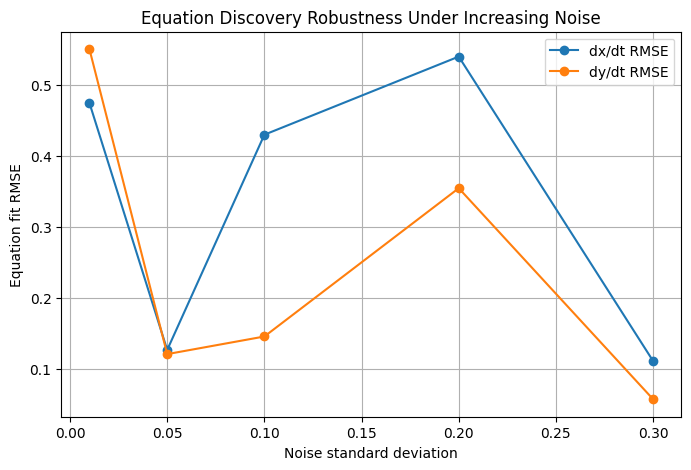

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(robustness_df["noise_std"], robustness_df["dx_rmse"], marker="o", label="dx/dt RMSE")
plt.plot(robustness_df["noise_std"], robustness_df["dy_rmse"], marker="o", label="dy/dt RMSE")

plt.xlabel("Noise standard deviation")
plt.ylabel("Equation fit RMSE")
plt.title("Equation Discovery Robustness Under Increasing Noise")
plt.legend()
plt.grid(True)

plt.savefig("noise_robustness_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
files.download("noise_robustness_rmse.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

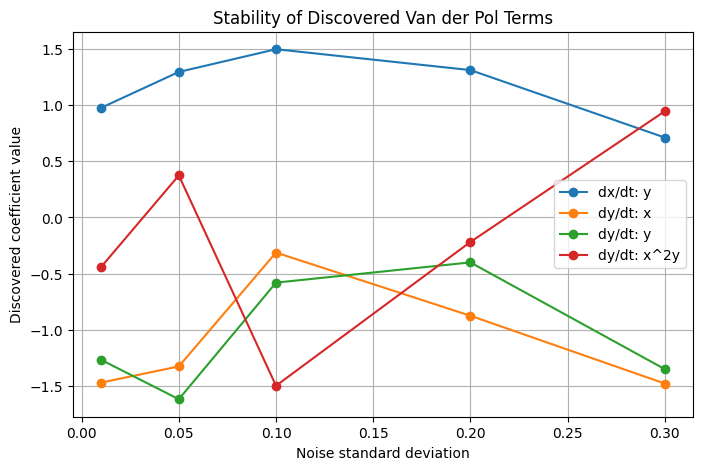

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(robustness_df["noise_std"], robustness_df["coef_dx_y"], marker="o", label="dx/dt: y")
plt.plot(robustness_df["noise_std"], robustness_df["coef_dy_x"], marker="o", label="dy/dt: x")
plt.plot(robustness_df["noise_std"], robustness_df["coef_dy_y"], marker="o", label="dy/dt: y")
plt.plot(robustness_df["noise_std"], robustness_df["coef_dy_x2y"], marker="o", label="dy/dt: x^2y")

plt.xlabel("Noise standard deviation")
plt.ylabel("Discovered coefficient value")
plt.title("Stability of Discovered Van der Pol Terms")
plt.legend()
plt.grid(True)

plt.savefig("noise_robustness_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
files.download("noise_robustness_coefficients.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>